# Clinical Risk Factors Analysis

This notebook explores clinical and physiological factors associated with different risk levels. The analysis includes data loading, cleaning, descriptive statistics, and visual exploration of key health indicators.

In [1]:
import pandas as pd
df = pd.read_csv("C:\\Users\\Adel computers\\Downloads\\Dataset.csv")
df.head()
df.info()
df.shape


<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   str    
dtypes: float64(7), int64(4), str(1)
memory usage: 113.1 KB


(1205, 12)

## Risk Level Distribution

Examine the frequency of each risk category to understand class balance and identify whether certain risk levels dominate the dataset.

In [5]:
df['Risk Level'].value_counts()

Risk Level
Low     713
High    474
Name: count, dtype: int64

## Remove Missing Target Values

Records without a defined **Risk Level** cannot be used for risk-based analysis. This step removes those observations.

In [11]:

df = df.dropna(subset=['Risk Level'])
df.shape

(1187, 12)

## Initial Missing Value Assessment

Check the dataset for missing values across all variables to identify data quality issues before further analysis.

In [13]:
df.isnull().sum()

Age                        0
Systolic BP                4
Diastolic                  2
BS                         1
Body Temp                  0
BMI                       14
Previous Complications     1
Preexisting Diabetes       1
Gestational Diabetes       0
Mental Health              0
Heart Rate                 1
Risk Level                 0
dtype: int64

## Data Cleaning

Remove remaining rows containing missing values to create a complete dataset suitable for statistical analysis and visualization.

In [14]:
df=df.dropna()
df.shape

(1166, 12)

## Verify Data Quality

Confirm that missing values have been successfully removed from all columns.

In [15]:
df.isnull().sum()

Age                       0
Systolic BP               0
Diastolic                 0
BS                        0
Body Temp                 0
BMI                       0
Previous Complications    0
Preexisting Diabetes      0
Gestational Diabetes      0
Mental Health             0
Heart Rate                0
Risk Level                0
dtype: int64

## Clinical Risk Factor Exploration

Investigate how demographic and clinical variables relate to risk levels through summary statistics and visual analysis.

## Mental Health Categories

Review the available mental health status categories present in the dataset.

In [20]:
df['Mental Health'].unique()

array([1, 0])

## Mental Health vs Risk Level

Analyze the proportion of risk levels within each mental health category to identify potential associations.

In [21]:
pd.crosstab(df['Mental Health'], df['Risk Level'], normalize='index')

Risk Level,High,Low
Mental Health,,
0,0.178893,0.821107
1,0.835476,0.164524


## Mean Clinical Measurements by Risk Level

Compare average values of age, heart rate, mental health score, blood sugar, and BMI across different risk groups.

In [23]:
df.groupby('Risk Level')[['Age','Heart Rate','Mental Health','BS','BMI']].mean()

,Age,Heart Rate,Mental Health,BS,BMI
Risk Level,,,,,
High,29.706897,80.068966,0.700431,9.745690,25.820259
Low,26.049858,72.978632,0.091168,6.052664,21.699430


## BMI Distribution Across Risk Levels

Visualize how Body Mass Index varies between risk categories and identify potential outliers or trends.

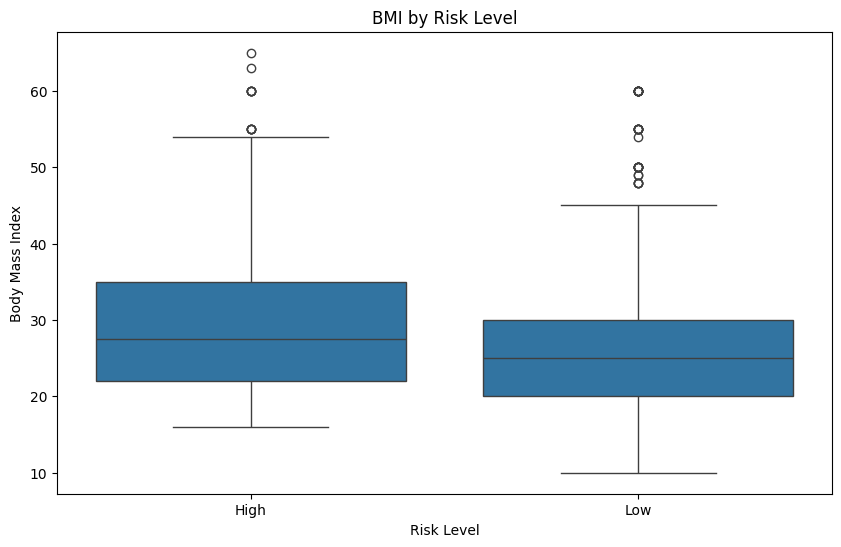

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns   

plt.figure(figsize=(10,6))
sns.boxplot(x='Risk Level', y= 'BMI', data=df)
plt.title('BMI by Risk Level')
plt.ylabel('Body Mass Index')
plt.show()

## Remove Invalid BMI Values

Exclude records with BMI equal to zero, as these values may represent measurement errors or missing information.

In [34]:

df = df[df['BMI'] != 0]
df.shape

(1165, 12)

## Blood Sugar Distribution by Risk Level

Assess differences in blood sugar measurements across risk groups using boxplot visualization.

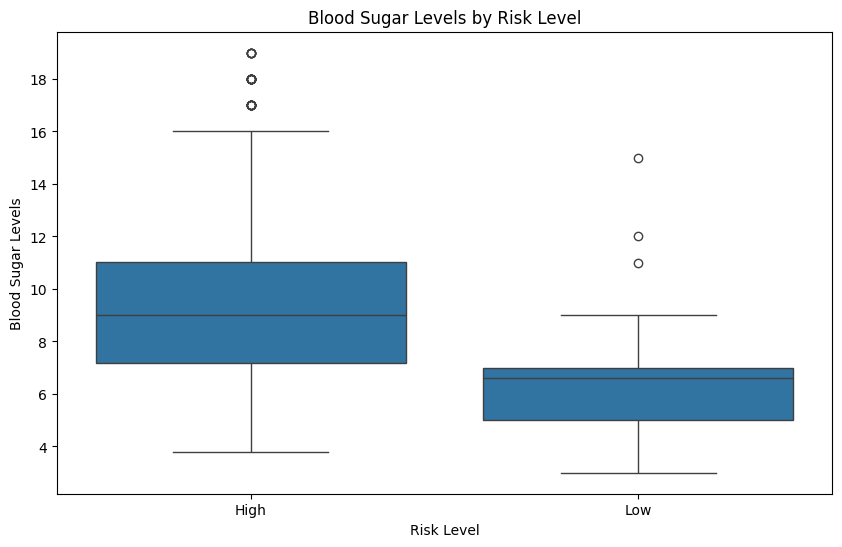

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns   

plt.figure(figsize=(10,6))
sns.boxplot(x='Risk Level', y= 'BS', data=df)
plt.title('Blood Sugar Levels by Risk Level')
plt.ylabel('Blood Sugar Levels')
plt.show()

## Age Distribution by Risk Level

Examine whether age varies systematically across risk categories and identify age-related risk patterns.

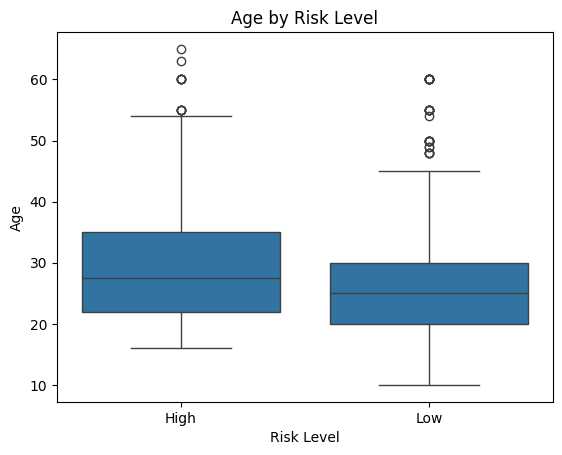

In [37]:

sns.boxplot(x='Risk Level', y= 'Age', data=df)
plt.title('Age by Risk Level')
plt.ylabel('Age')
plt.show()

## Heart Rate Distribution by Risk Level

Explore the relationship between heart rate and risk level to determine whether elevated or reduced heart rates are associated with higher risk.

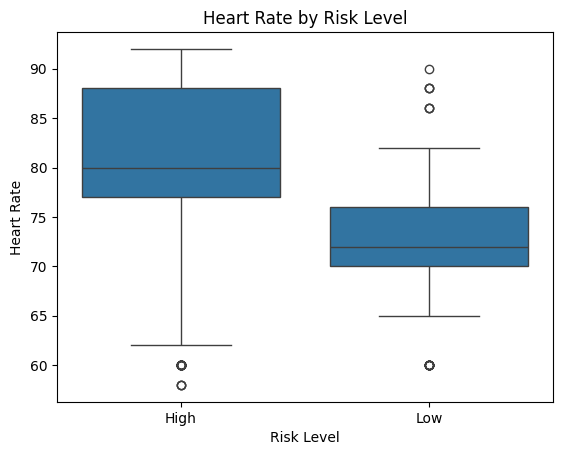

In [38]:
sns.boxplot(x='Risk Level', y= 'Heart Rate', data=df)
plt.title('Heart Rate by Risk Level')
plt.ylabel('Heart Rate')
plt.show()